# Laboratorio 5

- Iris Ayala
- Anggie Quezada
- Jonathan Diaz

Estado elegido: **Wisconsin (WI, FIPS 55)**

## Task 1.1

### a. Carga de los datos

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union
from matplotlib_scalebar.scalebar import ScaleBar

In [2]:
hospitales = gpd.read_file("datos/hospitales_eeuu.geojson")
condados = gpd.read_file("datos/condados_eeuu.geojson")
estados = gpd.read_file("datos/estados_eeuu.geojson")
poblacion = pd.read_csv("datos/poblacion_condados.csv")

# resumen de cada archivo: registros, crs y columnas
archivos = {"hospitales": hospitales, "condados": condados, "estados": estados, "poblacion": poblacion}
for nombre, df in archivos.items():
    crs = df.crs if isinstance(df, gpd.GeoDataFrame) else "no aplica"
    print(nombre, "| registros:", len(df), "| CRS:", crs)
    print("   columnas:", list(df.columns))

hospitales | registros: 7154 | CRS: EPSG:4326
   columnas: ['nombre', 'tipo', 'ciudad', 'estado', 'condado', 'fips_condado', 'camas_total', 'camas_icu', 'camas_licenciadas', 'ocupacion_total', 'ocupacion_icu', 'geometry']
condados | registros: 3221 | CRS: EPSG:4326
   columnas: ['fips', 'nombre', 'cod_estado', 'geometry']
estados | registros: 51 | CRS: EPSG:4326
   columnas: ['nombre', 'codigo', 'pais', 'geometry']
poblacion | registros: 3246 | CRS: no aplica
   columnas: ['fips', 'condado', 'estado', 'lat', 'lon', 'poblacion']


Los tres archivos geojson vienen en EPSG:4326 (WGS84), o sea en grados de latitud y longitud. El csv de población no tiene geometría, solo trae lat y lon como columnas normales, por eso no tiene CRS.

- hospitales: 7,154 registros. Lo que más se usa es `tipo`, `estado`, `camas_total`, `camas_icu` y las de ocupación.
- condados: 3,221 registros con `fips`, `nombre`, `cod_estado` y la geometría.
- estados: 51 registros (los 50 estados más DC).
- población: 3,246 registros, más que los condados porque trae filas que no son condados reales (ver inciso b).

### b. Limpieza

In [3]:
# quitar los fips >= 80000 (no son condados reales) y pasar a texto de 5 digitos
print("antes:", len(poblacion))
poblacion = poblacion[poblacion["fips"] < 80000].copy()
poblacion["fips"] = poblacion["fips"].astype(str).str.zfill(5)
print("despues:", len(poblacion))
poblacion.head(3)

antes: 3246
despues: 3144


,fips,condado,estado,lat,lon,poblacion
102,01001,Autauga,Alabama,32.539527,-86.644082,55869.0
103,01003,Baldwin,Alabama,30.727750,-87.722071,223234.0
104,01005,Barbour,Alabama,31.868263,-85.387129,24686.0


Se quitaron 102 filas, que son las de tipo "Out of AL", "Out of AK", etc. Quedan 3,144 condados con población. Todavía no coincide con los 3,221 de las geometrías, pero esa diferencia son sobre todo los municipios de Puerto Rico, que vienen en el geojson pero no en el csv. Para Wisconsin no afecta.

In [4]:
pct_nulos = hospitales["camas_total"].isna().mean() * 100
print("hospitales con camas_total nulo:", round(pct_nulos, 2), "%")
print("hospitales en WI antes de limpiar:", (hospitales["estado"] == "WI").sum())

hospitales = hospitales[hospitales["camas_total"].notna()].copy()
print("hospitales con camas:", len(hospitales))
print("hospitales con camas en WI:", (hospitales["estado"] == "WI").sum())

hospitales con camas_total nulo: 15.24 %
hospitales en WI antes de limpiar: 163
hospitales con camas: 6064
hospitales con camas en WI: 144


El 15.24% de los hospitales del país no trae `camas_total`. En Wisconsin había 163 hospitales y al quitar los que no tienen camas quedan **144**, todavía bastante arriba del mínimo de 50 que sugieren.

Hay que tener en cuenta que esos 19 hospitales que se quitaron sí existen, entonces la cobertura que sale más adelante probablemente está un poco subestimada.

### c. Filtro por estado y unión con población

In [5]:
hosp_wi = hospitales[hospitales["estado"] == "WI"].copy()
cond_wi = condados[condados["cod_estado"] == "55"].copy()
pob_wi = poblacion[poblacion["fips"].str[:2] == "55"]
estado_wi = estados[estados["codigo"] == "WI"].copy()

# union de geometria con poblacion usando el fips
cond_wi = cond_wi.merge(pob_wi[["fips", "poblacion"]], on="fips", how="left")

print("hospitales:", len(hosp_wi))
print("condados con geometria:", len(cond_wi))
print("condados en la tabla de poblacion:", len(pob_wi))
print("condados con poblacion despues de unir:", cond_wi["poblacion"].notna().sum())

hospitales: 144
condados con geometria: 72
condados en la tabla de poblacion: 72
condados con poblacion despues de unir: 72


Wisconsin tiene 72 condados y los 72 tienen población después de la unión, entonces no se perdió ninguno por el formato del fips. La población total del estado queda en unos 5.82 millones.

In [6]:
hosp_wi["tipo"].value_counts()

tipo
GENERAL ACUTE CARE    113
CRITICAL ACCESS        12
PSYCHIATRIC            11
LONG TERM CARE          5
REHABILITATION          3
Name: count, dtype: int64

Casi todos son de cuidados agudos generales (113). Después vienen los de acceso crítico (12), que son hospitales rurales pequeños, y unos pocos psiquiátricos, de cuidado prolongado y de rehabilitación.

### d. Reproyección

In [7]:
crs_m = "EPSG:3070"  # NAD83 / Wisconsin Transverse Mercator, en metros

hosp_m = hosp_wi.to_crs(crs_m)
cond_m = cond_wi.to_crs(crs_m)
estado_m = estado_wi.to_crs(crs_m)
print(cond_m.crs.name, "|", cond_m.crs.axis_info[0].unit_name)

NAD83 / Wisconsin Transverse Mercator | metre


Se usó **EPSG:3070 (NAD83 / Wisconsin Transverse Mercator, WTM)**, que es el sistema que usa el propio gobierno de Wisconsin (WisDOT y el DNR) para su información geográfica en todo el estado.

¿Por qué este y no otro?

- Está en metros, entonces los buffers de 10, 25 y 50 km salen con el tamaño correcto. En EPSG:4326 un grado de longitud a la latitud de Wisconsin (~44.5°N) mide como 79 km y uno de latitud 111 km, entonces un círculo en grados saldría como óvalo.
- Es una Transversa de Mercator con el meridiano central en 90°W, que pasa casi por en medio del estado, y factor de escala k0 = 0.9996. En una transversa de Mercator la distorsión de escala depende de qué tan lejos estás del meridiano central (en este eje este-oeste). Wisconsin mide unos 475 km de ancho, así que lo más lejos que se llega del meridiano son unos 250 km y el error de escala se mantiene más o menos entre -0.04% y +0.03%. En 25 km eso es menos de 10 metros.
- Es conforme, o sea que conserva ángulos y formas locales, y para un estado de este tamaño las áreas tampoco se distorsionan casi nada, lo cual importa porque en el Task 1.3 se calculan fracciones de área.
- La otra opción eran las State Plane de Wisconsin, pero esas son tres zonas (norte, centro y sur), así que habría que partir el estado. UTM tampoco sirve muy bien porque Wisconsin cae entre las zonas 15 y 16. WTM se creó justo para tener una sola proyección para todo el estado.

### e. Mapa base

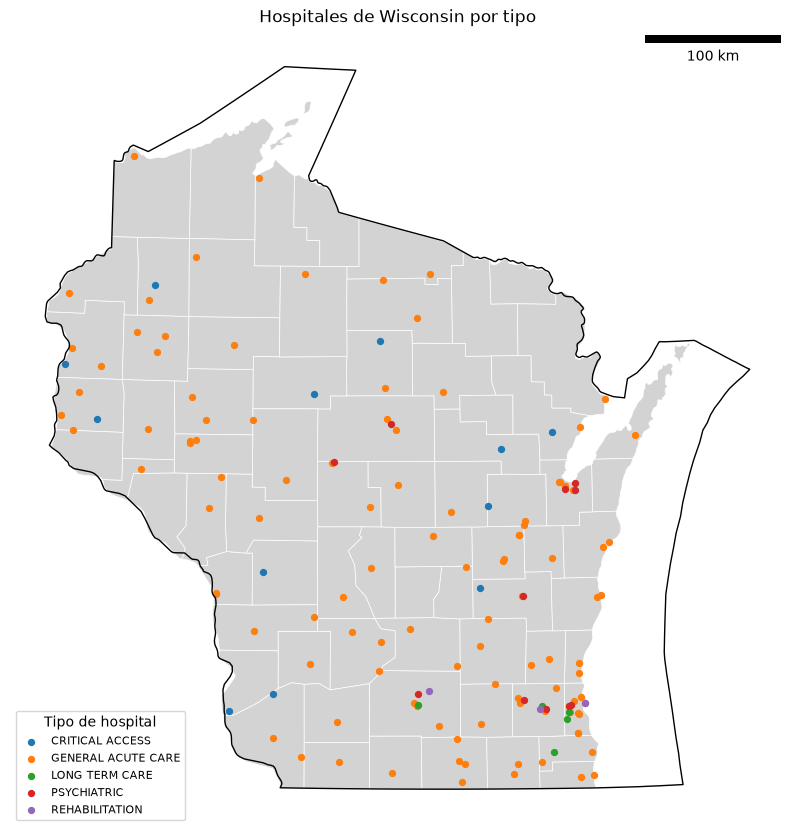

In [8]:
fig, ax = plt.subplots(figsize=(10, 11))
cond_m.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
hosp_m.plot(ax=ax, column="tipo", categorical=True, cmap="tab10", markersize=18, legend=True,
            legend_kwds={"loc": "lower left", "fontsize": 8, "title": "Tipo de hospital"})
estado_m.boundary.plot(ax=ax, color="black", linewidth=1)
ax.add_artist(ScaleBar(1, units="m", location="upper right"))  # 1 unidad del mapa = 1 metro
ax.set_title("Hospitales de Wisconsin por tipo")
ax.set_axis_off()
plt.show()

Los hospitales se juntan bastante en el sureste (Milwaukee, Waukesha, Madison) y en el corredor de Green Bay, Appleton y Oshkosh. En el norte están mucho más separados y hay condados sin ningún punto, sobre todo en la frontera con Michigan. Los de acceso crítico (azul) salen casi todos en zonas rurales, como era de esperar.

El contorno del estado incluye una parte del lago Michigan porque el límite oficial del estado entra en el agua, por eso se ve el espacio blanco a la derecha.

## Task 1.2

In [9]:
# a cada hospital se le asigna el condado donde cae su punto
hosp_cond = gpd.sjoin(hosp_m, cond_m[["fips", "geometry"]], predicate="within")

por_condado = hosp_cond.groupby("fips").agg(n_hospitales=("nombre", "count"),
                                            camas_total=("camas_total", "sum"),
                                            camas_icu=("camas_icu", "sum")).reset_index()

tabla = cond_m[["fips", "nombre", "poblacion"]].merge(por_condado, on="fips", how="left")
tabla[["n_hospitales", "camas_total", "camas_icu"]] = tabla[["n_hospitales", "camas_total", "camas_icu"]].fillna(0)
tabla["camas_10k"] = tabla["camas_total"] / tabla["poblacion"] * 10000
tabla["icu_10k"] = tabla["camas_icu"] / tabla["poblacion"] * 10000

print("hospitales asignados a un condado:", len(hosp_cond), "de", len(hosp_m))
print("condados sin hospital:", (tabla["n_hospitales"] == 0).sum())
tabla.sort_values("nombre").round(2)

hospitales asignados a un condado: 144 de 144
condados sin hospital: 9


,fips,nombre,poblacion,n_hospitales,camas_total,camas_icu,camas_10k,icu_10k
66,55001,Adams,20220.0,1.0,25.0,0.0,12.36,0.00
13,55003,Ashland,15562.0,1.0,25.0,0.0,16.06,0.00
14,55005,Barron,45244.0,3.0,90.0,5.0,19.89,1.11
15,55007,Bayfield,15036.0,0.0,0.0,0.0,0.00,0.00
70,55009,Brown,264542.0,8.0,828.0,60.0,31.30,2.27
...,...,...,...,...,...,...,...,...
25,55133,Waukesha,404198.0,8.0,770.0,64.0,19.05,1.58
41,55135,Waupaca,50990.0,1.0,25.0,4.0,4.90,0.78
71,55137,Waushara,24443.0,1.0,25.0,0.0,10.23,0.00
26,55139,Winnebago,171907.0,4.0,357.0,60.0,20.77,3.49


Todos los hospitales cayeron dentro de algún condado, y 9 condados no tienen ningún hospital con datos de camas. Las camas UCI que vienen nulas (55 de los 144 hospitales) se cuentan como 0 en la suma, entonces la columna de UCI probablemente se queda corta en varios condados.

### a. Condados con menos camas por habitante (población > 10,000)

In [10]:
tabla[tabla["poblacion"] > 10000].sort_values("camas_10k").head(5).round(2)

,fips,nombre,poblacion,n_hospitales,camas_total,camas_icu,camas_10k,icu_10k
59,55061,Kewaunee,20434.0,0.0,0.0,0.0,0.0,0.0
57,55093,Pierce,42754.0,0.0,0.0,0.0,0.0,0.0
15,55007,Bayfield,15036.0,0.0,0.0,0.0,0.0,0.0
53,55077,Marquette,15574.0,0.0,0.0,0.0,0.0,0.0
27,55011,Buffalo,13031.0,0.0,0.0,0.0,0.0,0.0


Los cinco son condados **sin ningún hospital**: Kewaunee, Pierce, Bayfield, Marquette y Buffalo. Justo hay cinco condados de más de 10 mil habitantes con 0 camas, así que no hubo empates raros. Pierce es el más preocupante por población (casi 43 mil personas).

Pero no todos están igual de mal. Pierce queda pegado a Minneapolis-St. Paul, y Kewaunee está al lado de Green Bay, así que lo más seguro es que esa gente se vaya a atender al condado vecino o incluso a otro estado. Bayfield y Marquette sí están más metidos en zonas rurales. Por eso lo de "camas por habitante" sirve como primera alerta, pero hay que ver la distancia real (eso se hace en el Task 1.3 y en el Task 2).

### b. Condados con más camas por habitante

In [11]:
tabla.sort_values("camas_10k", ascending=False).head(5).round(2)

,fips,nombre,poblacion,n_hospitales,camas_total,camas_icu,camas_10k,icu_10k
12,55141,Wood,72999.0,3.0,291.0,27.0,39.86,3.70
42,55035,Eau Claire,104646.0,3.0,374.0,48.0,35.74,4.59
56,55091,Pepin,7287.0,1.0,25.0,0.0,34.31,0.00
63,55079,Milwaukee,945726.0,15.0,3237.0,533.0,34.23,5.64
4,55063,La Crosse,118016.0,2.0,395.0,52.0,33.47,4.41


Los de más camas por habitante son Wood, Eau Claire, Pepin, Milwaukee y La Crosse.

In [12]:
# que hospitales hay en esos condados
top5 = tabla.sort_values("camas_10k", ascending=False).head(5)["fips"]
hosp_cond[hosp_cond["fips"].isin(top5)][["nombre", "ciudad", "tipo", "camas_total"]].sort_values("ciudad")

,nombre,ciudad,tipo,camas_total
1685,OAKLEAF SURGICAL HOSPITAL,ALTOONA,GENERAL ACUTE CARE,13.0
7097,CHIPPEWA VALLEY HSPTL,DURAND,GENERAL ACUTE CARE,25.0
4079,MAYO CLINIC HEALTH SYSTEM EAU CLAIRE HOSPITAL,EAU CLAIRE,GENERAL ACUTE CARE,193.0
3172,SACRED HEART HSPTL,EAU CLAIRE,GENERAL ACUTE CARE,168.0
5765,WHEATON FRANCISCAN HEALTHCARE- FRANKLIN INC,FRANKLIN,GENERAL ACUTE CARE,44.0
5722,MIDWEST ORTHOPEDIC SPECIALTY HOSPITAL LLC,FRANKLIN,GENERAL ACUTE CARE,16.0
5843,ORTHOPAEDIC HSPTL OF WI,GLENDALE,GENERAL ACUTE CARE,30.0
1659,POST ACUTE MEDICAL SPECIALTY HOSPITAL OF MILWA...,GREENFIELD,LONG TERM CARE,56.0
5108,GUNDERSEN LUTH MED CTR,LA CROSSE,GENERAL ACUTE CARE,253.0
5163,MAYO CLINIC HLTH SYSTEM- FRANCISCAN MED CTR,LA CROSSE,GENERAL ACUTE CARE,142.0


Revisando qué hospitales hay ahí, la mayoría de estos casos no significa que la gente del condado tenga más acceso. Son condados con hospitales regionales que atienden a mucha gente de afuera:

- **Wood** tiene Marshfield, donde está Saint Joseph's (230 camas), el hospital de referencia de todo el centro y norte de Wisconsin.
- **Eau Claire** y **La Crosse** son los centros médicos del oeste del estado (Mayo Clinic, Sacred Heart, Gundersen). La Crosse además recibe pacientes de Minnesota y de Iowa.
- **Milwaukee** concentra hospitales grandes y especializados (Froedtert, el hospital de niños, St. Luke's, el psiquiátrico del condado). Ahí van pacientes de todo el sureste.
- **Pepin** es otra cosa: tiene un solo hospital de 25 camas, pero la población es tan pequeña (7 mil) que la división sale alta. Eso más bien es un efecto de dividir entre poco.

Entonces un número alto de camas por habitante casi siempre quiere decir que el condado funciona como "centro" de una región, no que sus habitantes tengan algo de sobra. Si a esas camas se les sumara la gente de los condados vecinos que llega a usarlas, la tasa bajaría bastante.

### c. Distribuciones

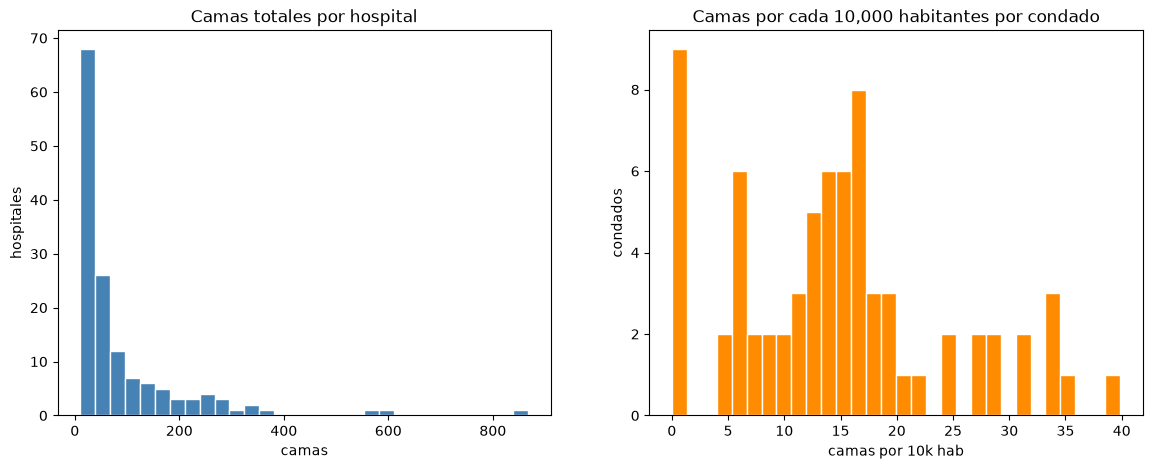

count    144.0
mean      88.9
std      119.7
min       10.0
25%       25.0
50%       41.0
75%      102.2
max      868.0
Name: camas_total, dtype: float64
count    72.0
mean     14.7
std       9.8
min       0.0
25%       7.7
50%      14.5
75%      18.2
max      39.9
Name: camas_10k, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hosp_m["camas_total"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Camas totales por hospital")
axes[0].set_xlabel("camas")
axes[0].set_ylabel("hospitales")

axes[1].hist(tabla["camas_10k"], bins=30, color="darkorange", edgecolor="white")
axes[1].set_title("Camas por cada 10,000 habitantes por condado")
axes[1].set_xlabel("camas por 10k hab")
axes[1].set_ylabel("condados")
plt.show()

print(hosp_m["camas_total"].describe().round(1))
print(tabla["camas_10k"].describe().round(1))

**Camas por hospital:** está muy sesgada a la derecha. La mediana es 41 camas pero el promedio es 89, porque unos pocos hospitales grandes jalan el promedio hacia arriba (St. Luke's con 868, Froedtert con 581). Hay un pico muy marcado en los hospitales chiquitos: 46 de los 144 tienen exactamente 25 camas, que es el límite que se le pone a los hospitales de acceso crítico en EE.UU. Entonces en Wisconsin conviven dos tipos de hospital muy distintos, muchos pequeños rurales y pocos grandes en ciudades.

**Camas por 10k habitantes por condado:** también es asimétrica pero de otra forma. Hay un bloque de 9 condados en 0 (los que no tienen hospital), después la mayoría queda entre 10 y 20 (mediana 14.5) y luego una cola a la derecha con los condados que tienen hospitales regionales, hasta casi 40.

Para la cobertura esto quiere decir que no se puede tratar igual a todos los hospitales. Un buffer de 25 km alrededor de un hospital de 25 camas cuenta lo mismo que uno alrededor de uno de 800, y obviamente no atienden lo mismo. También quiere decir que el promedio no sirve mucho para describir el estado, es mejor ver la mediana y fijarse aparte en los condados en cero.

## Task 1.3

### a. Buffers de cobertura

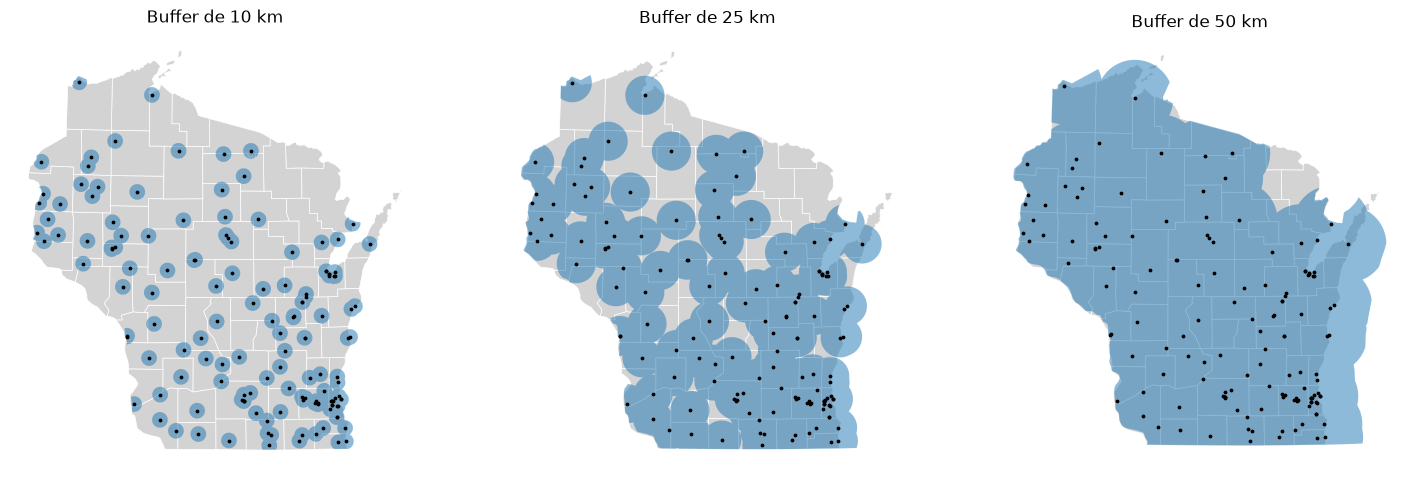

In [14]:
radios = [10, 25, 50]
estado_geom = estado_m.geometry.iloc[0]
cobertura = {}
for r in radios:
    buffers = hosp_m.buffer(r * 1000)  # radio en metros
    cobertura[r] = unary_union(list(buffers))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, r in zip(axes, radios):
    cond_m.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
    gpd.GeoSeries([cobertura[r].intersection(estado_geom)], crs=crs_m).plot(ax=ax, color="tab:blue", alpha=0.5)
    hosp_m.plot(ax=ax, color="black", markersize=3)
    ax.set_title("Buffer de " + str(r) + " km")
    ax.set_axis_off()
plt.show()

A 10 km los buffers casi solo cubren las ciudades y quedan muchos huecos. A 25 km ya se cubre la mayor parte del sur y del centro, y lo que queda vacío es sobre todo el norte. A 50 km prácticamente todo el estado queda adentro.

### b. Cobertura poblacional

In [15]:
pob_total = cond_m["poblacion"].sum()
area_cond = cond_m.area

filas = []
for r in radios:
    # fraccion del area de cada condado dentro del buffer, la poblacion se asume uniforme
    frac = cond_m.intersection(cobertura[r]).area / area_cond
    cond_m["frac_" + str(r)] = frac
    cubierta = (frac * cond_m["poblacion"]).sum()
    filas.append({"radio_km": r,
                  "poblacion_cubierta": round(cubierta),
                  "poblacion_total": round(pob_total),
                  "porcentaje": round(cubierta / pob_total * 100, 2)})

tabla_cob = pd.DataFrame(filas)
tabla_cob

,radio_km,poblacion_cubierta,poblacion_total,porcentaje
0,10,2653699,5822434,45.58
1,25,5371347,5822434,92.25
2,50,5787960,5822434,99.41


| radio | % de población cubierta |
|---|---|
| 10 km | 45.6% |
| 25 km | 92.3% |
| 50 km | 99.4% |

El salto más grande es de 10 a 25 km, de menos de la mitad a más del 90%. Después de 25 km lo que se gana ya es poco, porque la gente que falta vive en zonas muy dispersas del norte.

Esto se calculó asumiendo que la población está repartida igual dentro de cada condado, lo cual no es cierto: la gente vive más en los pueblos y los pueblos suelen tener el hospital cerca. Entonces el 45.6% a 10 km probablemente está subestimado. Además solo se tomaron en cuenta hospitales de Wisconsin, y en la frontera hay hospitales de Minnesota, Michigan, Iowa e Illinois (Duluth, Minneapolis, Iron Mountain) que también atienden a gente de Wisconsin.

### c. Mapa de cobertura a 25 km

In [16]:
def clasificar(f):
    if f >= 0.999:  # margen por errores de redondeo en las areas
        return "Completamente cubierto"
    elif f > 0:
        return "Parcialmente cubierto"
    return "No cubierto"

cond_m["cobertura_25"] = cond_m["frac_25"].apply(clasificar)
cond_m["cobertura_25"].value_counts()

cobertura_25
Parcialmente cubierto     61
Completamente cubierto    10
No cubierto                1
Name: count, dtype: int64

Solo 10 condados quedan completamente cubiertos, 61 parcialmente y 1 nada (Florence).

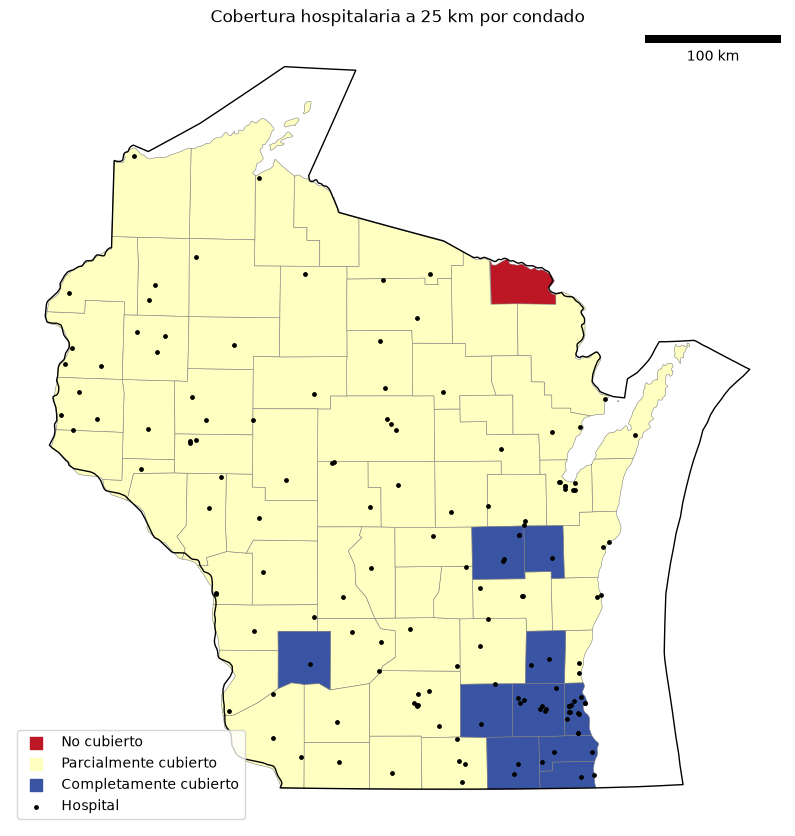

In [17]:
cmap = plt.get_cmap("RdYlBu")
colores = {"No cubierto": cmap(0.05), "Parcialmente cubierto": cmap(0.5), "Completamente cubierto": cmap(0.95)}

fig, ax = plt.subplots(figsize=(10, 11))
for cat, color in colores.items():
    parte = cond_m[cond_m["cobertura_25"] == cat]
    if len(parte) > 0:
        parte.plot(ax=ax, color=color, edgecolor="gray", linewidth=0.4)
    ax.scatter([], [], color=color, marker="s", s=80, label=cat)

hosp_m.plot(ax=ax, color="black", markersize=6, label="Hospital")
estado_m.boundary.plot(ax=ax, color="black", linewidth=1)
ax.add_artist(ScaleBar(1, units="m", location="upper right"))
ax.legend(loc="lower left")
ax.set_title("Cobertura hospitalaria a 25 km por condado")
ax.set_axis_off()
plt.show()

Que casi todo salga "parcialmente cubierto" se explica porque los condados de Wisconsin son grandes comparados con un círculo de 25 km. Basta con que una esquina del condado quede fuera para que ya no cuente como completo. Los completos están en el sureste (alrededor de Milwaukee), en Madison y en la zona de Appleton-Oshkosh, que es donde hay más hospitales juntos.

In [18]:
cond_m[["nombre", "poblacion", "frac_25", "cobertura_25"]].sort_values("frac_25").head(10).round(3)

,nombre,poblacion,frac_25,cobertura_25
43,Florence,4295.0,0.000,No cubierto
44,Forest,9004.0,0.065,Parcialmente cubierto
61,Iron,5687.0,0.084,Parcialmente cubierto
52,Marinette,40350.0,0.194,Parcialmente cubierto
60,Douglas,43150.0,0.270,Parcialmente cubierto
15,Bayfield,15036.0,0.288,Parcialmente cubierto
21,Sawyer,16558.0,0.344,Parcialmente cubierto
38,Price,13351.0,0.350,Parcialmente cubierto
27,Buffalo,13031.0,0.434,Parcialmente cubierto
36,Menominee,4556.0,0.459,Parcialmente cubierto


Los que tienen menos fracción cubierta están todos en el norte: Florence (0%), Forest (6.5%), Iron (8.4%), Marinette, Douglas, Bayfield, Sawyer y Price. Es la zona de bosques y lagos, con poca población y los hospitales muy separados.

Ojo con Florence, Iron y Douglas: están en la frontera, y del otro lado hay hospitales (Iron Mountain en Michigan, Duluth en Minnesota) que este análisis no ve porque solo se filtraron los de Wisconsin. Así que la brecha real ahí puede ser menor. Forest, Sawyer y Price sí están en medio del estado, y esos parecen ser los huecos de verdad.

**Prompts utilizados:**

- "Del task 1 ayudame con el codigo para limpieza de datos y el calculo de los buffers."